<h2>Capstone Two: Data Wrangling

Collecting and compiling the data. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
csv_files = [
    '../data/stretcher_2013_2015.csv',
    '../data/stretcher_2016_2017.csv',
    '../data/stretcher_2018_2019.csv',
    '../data/stretcher_2020_2021.csv',
    '../data/stretcher_2022_2023.csv',
]

df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486812 entries, 0 to 486811
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Discharge Date                    486812 non-null  object 
 1   Discharge Time                    486812 non-null  object 
 2   Alloy                             486812 non-null  object 
 3   JOB                               486812 non-null  int64  
 4   LOT                               486812 non-null  object 
 5   MI Piece                          486812 non-null  int64  
 6   MI Thickness                      486812 non-null  float64
 7   MI Width                          486812 non-null  float64
 8   MI Length                         486812 non-null  float64
 9   Delay                             486812 non-null  float64
 10  Prestretch Force P605             486812 non-null  int64  
 11  Stretch Target P604               486812 non-null  f

In [6]:
# Update column types
df['Alloy'] = df['Alloy'].astype(str)
df['JOB'] = df['JOB'].astype(str)
df['LOT'] = df['LOT'].astype(str)
df['MI Piece'] = df['MI Piece'].astype(str)
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')
df['Step 11 Start_date'] = pd.to_datetime(df['Step 11 Start_date'], errors='coerce')
df['Discharge'] = pd.to_datetime(
    df['Discharge Date'].astype(str) + ' ' + df['Discharge Time'],
    format='%Y-%m-%d %I:%M:%S %p',
    errors='coerce'
)
df['Step 11 duration'] = pd.to_timedelta(df['Step 11 duration'], errors='coerce')
df['Step 11 Start_datetime'] = pd.to_datetime(
    df['Step 11 Start_date'].astype(str) + ' ' + df['Step 11 Start_time'],
    format='%Y-%m-%d %I:%M:%S %p',
    errors='coerce'
)

In [7]:
df.dtypes

Discharge Date                       datetime64[ns]
Discharge Time                               object
Alloy                                        object
JOB                                          object
LOT                                          object
MI Piece                                     object
MI Thickness                                float64
MI Width                                    float64
MI Length                                   float64
Delay                                       float64
Prestretch Force P605                         int64
Stretch Target P604                         float64
Yield Point P610                              int64
Stretch Percent P702                        float64
Max Stretch Force P703                        int64
Step 11 Start_date                   datetime64[ns]
Step 11 Start_time                           object
Step 11 duration                    timedelta64[ns]
Pre Stretch Measured Length P715            float64
Length P601 

In [8]:
pd.set_option('display.max_columns', None)
df.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime
0,2013-01-01,12:18:57 AM,XR7AT0K50,3179890,622597A3,1,3.988,56.25,355.76,8.2,6476512,2.0,6580376,2.178052,8449903,2013-01-01,12:17:16 AM,0 days 00:00:07,353.6535,355.76,56.25,3.988,361.3563,6476512,6580376,6476512,8449903,2013-01-01 00:18:57,2013-01-01 00:17:16
1,2013-01-01,12:23:03 AM,XR7AT0K50,3162736,624670A6,1,3.988,56.25,358.05,12.3,6476512,2.0,6773286,2.187799,8686119,2013-01-01,12:21:19 AM,0 days 00:00:07.010000,355.9468,358.05,56.25,3.988,363.7343,6476512,6773286,6476512,8686119,2013-01-01 00:23:03,2013-01-01 00:21:19
2,2013-01-01,12:27:42 AM,XR7AT0K50,3115404,627722A2,1,3.844,56.50,343.00,5.0,6242656,2.0,6449282,2.176928,8286410,2013-01-01,12:26:00 AM,0 days 00:00:15.720000,341.5384,343.00,56.50,3.844,348.9734,6242656,6449282,6242656,8286410,2013-01-01 00:27:42,2013-01-01 00:26:00
3,2013-01-01,12:31:53 AM,XR7AT0K50,3136864,627717A2,1,3.844,56.50,344.17,9.2,6242656,2.0,6458988,2.177896,8291038,2013-01-01,12:30:11 AM,0 days 00:00:15.630000,342.2903,344.17,56.50,3.844,349.7451,6242656,6458988,6242656,8291038,2013-01-01 00:31:53,2013-01-01 00:30:11
4,2013-01-01,12:56:20 AM,XR7AT0K50,3162724,624750A6,1,3.988,56.01,354.97,6.6,6476512,2.0,6779857,2.141514,8813926,2013-01-01,12:54:38 AM,0 days 00:00:13.810000,353.4370,354.97,56.01,3.988,361.0059,6476512,6779857,6476512,8813926,2013-01-01 00:56:20,2013-01-01 00:54:38


In [9]:
df.describe()

,Discharge Date,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime
count,486812,486812.000000,486812.000000,486812.000000,4.868120e+05,4.868120e+05,486812.000000,4.868120e+05,486812.000000,4.868120e+05,483276,483276,486812.000000,486811.000000,486812.000000,486812.000000,486812.000000,4.868120e+05,4.868120e+05,4.868120e+05,4.868120e+05,486812,483276
mean,2018-09-06 10:37:49.038561024,3.265410,60.637144,309.292554,1.167715e+02,4.806003e+06,2.014173,5.011267e+06,2.166925,6.903931e+06,2018-09-06 20:51:08.755741952,0 days 00:00:17.593557408,306.627637,308.404533,60.384151,3.253746,314.778996,4.806003e+06,5.011267e+06,4.774859e+06,6.903931e+06,2018-09-06 22:36:16.623811328,2018-09-07 08:49:34.782041600
min,2013-01-01 00:00:00,0.000000,0.000000,0.000000,-7.000000e+01,0.000000e+00,0.000000,0.000000e+00,-29.528930,0.000000e+00,2013-01-01 00:00:00,0 days 00:00:00,0.000000,0.000000,0.000000,0.000000,-93.360240,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2013-01-01 00:18:57,2013-01-01 00:17:16
25%,2016-05-01 00:00:00,2.050000,56.000000,278.120000,1.550000e+01,2.734886e+06,2.000000,2.814564e+06,2.055442,3.923569e+06,2016-04-22 00:00:00,0 days 00:00:09.530000,275.155475,277.410000,56.000000,2.050000,282.357475,2.734886e+06,2.814564e+06,2.646150e+06,3.923569e+06,2016-05-01 11:58:42.500000,2016-04-22 22:40:33.500000
50%,2018-09-19 00:00:00,2.784000,56.350000,331.180000,2.230000e+01,4.162312e+06,2.000000,4.443309e+06,2.133005,5.968046e+06,2018-09-20 00:00:00,0 days 00:00:16,330.536700,331.140000,56.335000,2.784000,337.739800,4.162312e+06,4.443309e+06,4.155816e+06,5.968046e+06,2018-09-19 14:56:27,2018-09-20 00:44:58.500000
75%,2021-03-29 00:00:00,4.000000,67.000000,339.250000,3.240000e+01,6.242656e+06,2.000000,6.530712e+06,2.306178,8.930662e+06,2021-04-04 00:00:00,0 days 00:00:20.530000,338.626025,339.160000,67.000000,4.000000,346.190725,6.242656e+06,6.530712e+06,6.214352e+06,8.930662e+06,2021-03-29 06:32:16.500000,2021-04-04 22:21:43
max,2023-09-14 00:00:00,10.298000,105.000000,525.000000,4.908176e+06,1.483524e+07,5.836300,2.109101e+07,5.229858,1.960351e+07,2023-09-14 00:00:00,0 days 00:57:53,466.472200,422.000000,105.000000,10.298000,424.573100,1.483524e+07,2.109101e+07,1.483524e+07,1.960351e+07,2023-09-14 09:29:14,2023-09-14 09:27:34
std,NaN,1.714741,7.893613,47.665188,1.218944e+04,2.887562e+06,0.193260,3.047752e+06,0.266263,4.076812e+06,NaN,0 days 00:00:22.623767078,54.233270,50.381988,8.719737,1.723578,50.673509,2.887562e+06,3.047752e+06,2.900424e+06,4.076812e+06,NaN,NaN


In [10]:
missing = pd.concat([df.isnull().sum(), 100 * df.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
Step 11 Start_datetime,3536,0.726358
Step 11 Start_date,3536,0.726358
Step 11 duration,3536,0.726358
Length P601,1,0.000205
Discharge,0,0.000000
Max Stretch Force P7034,0,0.000000
Yield Point P623,0,0.000000
Yield Point P6103,0,0.000000
Prestretch Force P6052,0,0.000000
Length after Stretch P716,0,0.000000


In [11]:
#See if this will work as a key
(df['JOB'] + '-' + df['LOT'] + '-' + df['MI Piece']).value_counts().head()

5180661-262068B0-2    5
6289261-375504B8-3    4
5033688-243969B3-2    4
7411022-754460B4-1    3
6587110-397968B9-1    3
Name: count, dtype: int64

In [12]:
#Added date and time to key
(df['Discharge Date'].astype(str) + '-' + df['Discharge Time'].astype(str) + '-' + df['JOB'] + '-' + df['LOT'] + '-' + df['MI Piece']).value_counts()

2023-02-26-4:13:09 AM-7685151-761658B4-2    2
2023-02-26-2:06:27 PM-7764018-475001B4-3    2
2023-02-26-2:21:33 PM-7764020-761660B0-1    2
2023-02-26-2:25:54 PM-7764020-761660B0-2    2
2023-02-26-2:30:38 PM-7755263-484737B2-1    2
                                           ..
2017-03-25-5:33:55 PM-4768412-216251B9-2    1
2017-03-25-5:29:48 PM-4768412-216251B9-1    1
2017-03-25-5:19:18 PM-4781492-218714B4-1    1
2017-03-25-5:15:08 PM-4768417-216247B7-7    1
2023-09-14-9:29:14 AM-8036701-502795B8-2    1
Name: count, Length: 486573, dtype: int64

In [13]:
# Create the key with date and time
df['key'] = df['Discharge Date'].astype(str) + '-' + df['Discharge Time'].astype(str) + '-' + df['JOB'] + '-' + df['LOT'] + '-' + df['MI Piece']

In [14]:
#How many are still duplicates?
key_counts = df['key'].value_counts()
duplicate_sum = key_counts[key_counts >= 2].sum()
duplicate_sum

478

In [15]:
# Stretch force is most import make sure take the highest force value of the duplicates and remove the other
#Compute diff_force column
df['diff_force'] = df['Max Stretch Force P703'] - df['Max Stretch Force P7034']

In [16]:
duplicate_keys = df[df.duplicated('key', keep=False)].copy()

#Keep only the max-force row per duplicate group
max_force_rows = duplicate_keys.loc[
    duplicate_keys.groupby('key')['Max Stretch Force P703'].idxmax()
]

#Get non-duplicate rows 
non_duplicates = df[~df['key'].isin(duplicate_keys['key'])]

#Combine max-force rows with non-duplicate rows
df = pd.concat([non_duplicates, max_force_rows], ignore_index=True)
df.drop(columns=['diff_force'], inplace=True)

In [17]:
row_count_pre_clean = df['key'].count()
row_count_pre_clean

486573

In [18]:
zero_stats = (df == 0).sum().sort_values(ascending=False)
zero_stats

Yield Point P610                    5699
Yield Point P6103                   5699
Pre Stretch Measured Length P715    3557
Yield Point P623                    2629
Width P602                          1941
Length P603                         1777
Length P601                         1490
Length after Stretch P716            926
Delay                                124
MI Length                             72
Stretch Percent P702                  72
Prestretch Force P6052                68
Prestretch Force P605                 68
Stretch Target P604                   68
MI Width                              68
MI Thickness                          68
Max Stretch Force P703                33
Max Stretch Force P7034               33
Discharge                              0
Step 11 Start_datetime                 0
Discharge Date                         0
Step 11 Start_date                     0
Step 11 duration                       0
Step 11 Start_time                     0
Discharge Time  

In [19]:
df_zero_thickness = df[df['MI Thickness'] == 0]
df_zero_thickness.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key
14785,2013-07-15,4:49:13 PM,XR7AT4K75,3332345,649332A4,2,0.0,55.99,0.0,-0.6,4305000,2.0,4305000,2.110165,5867120,2013-07-15,4:47:35 PM,0 days 00:00:15.160000,286.7633,289.96,55.99,3.075,292.8145,4305000,4305000,4305000,5867120,2013-07-15 16:49:13,2013-07-15 16:47:35,2013-07-15-4:49:13 PM-3332345-649332A4-2
14882,2013-07-16,2:48:07 PM,XR7AT0K50,3326678,639803A6,1,0.0,75.00,0.0,1.0,6320550,2.0,6714148,2.175465,8519332,2013-07-16,2:46:21 PM,0 days 00:00:16.440000,333.0818,340.00,75.00,2.906,340.3278,6320550,6714148,6320550,8519332,2013-07-16 14:48:07,2013-07-16 14:46:21,2013-07-16-2:48:07 PM-3326678-639803A6-1
14903,2013-07-16,11:14:12 PM,XR7AT0K50,3331996,647431A6,1,0.0,56.00,0.0,7.0,4162312,2.0,4366972,2.148323,5553410,2013-07-16,11:12:31 PM,0 days 00:00:21.890000,352.7748,356.00,56.00,2.563,360.3536,4162312,4366972,4162312,5553410,2013-07-16 23:14:12,2013-07-16 23:12:31,2013-07-16-11:14:12 PM-3331996-647431A6-1
15452,2013-07-23,3:40:11 AM,XVKKT7H55,3344281,647003A3,1,0.0,67.79,0.0,16.7,11832870,1.7,13112730,1.767609,16685000,2013-07-23,3:38:00 AM,0 days 00:00:09.820000,222.8423,224.15,67.79,6.090,226.7813,11832870,13112730,11832870,16685000,2013-07-23 03:40:11,2013-07-23 03:38:00,2013-07-23-3:40:11 AM-3344281-647003A3-1
31758,2014-01-18,9:07:12 PM,XR7AT0K75,3484188,668463A3,1,0.0,0.00,0.0,48.4,6065514,0.0,6359543,2.116790,8805682,2014-01-18,9:05:35 PM,0 days 00:00:17.640000,328.9226,332.40,68.50,3.588,335.8853,6065514,6359543,6065514,8805682,2014-01-18 21:07:12,2014-01-18 21:05:35,2014-01-18-9:07:12 PM-3484188-668463A3-1


In [20]:
#No way to infer the missing values so remove those rows
df.drop(df[df['MI Thickness'] == 0].index, inplace=True) 

In [21]:
df_zero_width = df[df['MI Width'] == 0]
df_zero_width.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key
100116,2015-10-19,12:28:08 PM,XVKKT7H51,0,151138B5,0,4.060,0.0,0.0,124430.9,6593440,1.7,6935002,0.000000,8874542,2015-10-19,12:29:58 PM,0 days 00:00:21.760000,261.5624,0.00,0.00,0.000,0.000,6593440,6935002,6593440,8874542,2015-10-19 12:28:08,2015-10-19 12:29:58,2015-10-19-12:28:08 PM-0-151138B5-0
100145,2015-10-19,4:10:33 PM,XR6AT0K61,0,152891B8,0,2.335,0.0,0.0,124653.8,1348462,2.0,5358045,0.000000,9341594,2015-10-19,4:12:51 PM,0 days 00:00:13.580000,292.2637,0.00,0.00,0.000,0.000,1348462,5358045,5358045,9341594,2015-10-19 16:10:33,2015-10-19 16:12:51,2015-10-19-4:10:33 PM-0-152891B8-0
100402,2015-10-21,12:07:03 PM,XR7AT0K75,0,128339B9,0,3.040,0.0,0.0,127286.4,5139120,2.0,2874368,0.000000,3928348,2015-10-21,12:05:31 PM,0 days 00:00:17.510000,299.1341,0.00,0.00,0.000,0.000,5139120,2874368,2771440,3928348,2015-10-21 12:07:03,2015-10-21 12:05:31,2015-10-21-12:07:03 PM-0-128339B9-0
100403,2015-10-21,12:07:03 PM,XR7AT0K75,0,151326B6,0,2.020,0.0,0.0,127286.4,2771440,2.0,2874368,0.000000,3928348,2015-10-21,12:05:31 PM,0 days 00:00:17.510000,299.1341,0.00,0.00,0.000,0.000,2771440,2874368,2771440,3928348,2015-10-21 12:07:03,2015-10-21 12:05:31,2015-10-21-12:07:03 PM-0-151326B6-0
138734,2016-09-24,7:28:56 AM,#CALC!,4575122,195117B7,2,3.228,0.0,0.0,53.1,5242272,2.0,5993144,2.288848,7407261,2016-09-24,7:27:16 AM,0 days 00:00:11,326.9017,326.82,56.43,3.228,334.384,5242272,5993144,5242272,7407261,2016-09-24 07:28:56,2016-09-24 07:27:16,2016-09-24-7:28:56 AM-4575122-195117B7-2


In [22]:
#Use column Width P602 where MI Width is zero
df.loc[df['MI Width'] == 0, 'MI Width'] = df['Width P602']

#No way to infer the remaining missing values so remove those rows
df.drop(df[df['MI Width'] == 0].index, inplace=True) 

In [23]:
df_zero_stretch_target = df[df['Stretch Target P604'] == 0]
df_zero_stretch_target.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key
22668,2013-10-14,1:34:19 AM,XVKKT6H61,3383705,652529A9,2,2.354,72.00,342.0,32.6,0,0.0,1694880,2.152941,2654826,2013-10-14,1:32:38 AM,0 days 00:00:20.510000,338.5773,342.0,72.00,2.354,345.8666,0,1694880,1694880,2654826,2013-10-14 01:34:19,2013-10-14 01:32:38,2013-10-14-1:34:19 AM-3383705-652529A9-2
22997,2013-10-16,2:58:39 PM,XR7AT0K75,3395562,656091A6,1,1.826,68.46,361.2,-4.3,0,0.0,3139484,2.113157,4162563,2013-10-16,2:57:00 PM,0 days 00:00:20.860000,358.4596,361.2,68.46,1.826,366.0344,0,3139484,3086853,4162563,2013-10-16 14:58:39,2013-10-16 14:57:00,2013-10-16-2:58:39 PM-3395562-656091A6-1
23159,2013-10-18,1:07:18 PM,XR6AT0K61,3410050,630713A6,2,2.606,67.00,335.0,1601.4,0,0.0,2566649,1.962955,3925308,2013-10-18,1:05:37 PM,0 days 00:00:17.140000,330.9328,335.0,67.00,2.606,337.4289,0,2566649,1833321,3925308,2013-10-18 13:07:18,2013-10-18 13:05:37,2013-10-18-1:07:18 PM-3410050-630713A6-2
23208,2013-10-18,8:02:10 PM,XR6AT0K61,3410046,630519A7,2,2.086,88.00,362.0,1.4,0,0.0,1927464,2.333700,2907456,2013-10-18,8:00:31 PM,0 days 00:00:09.220000,359.2515,362.0,88.00,2.086,367.6353,0,1927464,1927464,2907456,2013-10-18 20:02:10,2013-10-18 20:00:31,2013-10-18-8:02:10 PM-3410046-630519A7-2
23368,2013-10-20,4:35:42 AM,XVKKT7H51,3403307,663339A0,1,4.795,63.00,238.0,10.9,0,0.0,9751736,1.790912,12173420,2013-10-20,4:33:36 AM,0 days 00:00:09.700000,232.1427,238.0,63.00,4.795,236.3002,0,9751736,8760465,12173420,2013-10-20 04:35:42,2013-10-20 04:33:36,2013-10-20-4:35:42 AM-3403307-663339A0-1


In [24]:
df_zero_stretch_percent = df[df['Stretch Percent P702'] == 0]
df_zero_stretch_percent.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key
1715,2013-01-29,2:07:44 PM,XR7AT0K50,0,625343A9,0,3.588,56.22047,290.315,591120.7,5826912,2.0,6604415,0.0,8484100,2013-01-29,2:09:06 PM,0 days 00:00:10.090000,330.0179,0.00,0.00,0.000,0.0000,5826912,6604415,6242656,8484100,2013-01-29 14:07:44,2013-01-29 14:09:06,2013-01-29-2:07:44 PM-0-625343A9-0
1723,2013-01-29,5:27:55 PM,XR7AT0K50,3117647,753240A1,1,3.844,56.25000,340.640,151.2,6242656,2.0,0,0.0,0,2013-01-29,7:24:52 PM,0 days 00:00:22.500000,339.9242,340.64,56.25,3.844,339.4536,6242656,0,0,0,2013-01-29 17:27:55,2013-01-29 19:24:52,2013-01-29-5:27:55 PM-3117647-753240A1-1
9034,2013-05-02,4:13:44 AM,XR2AT1K24,3266744,638701A3,1,2.563,58.00000,244.500,11.6,4310966,2.0,4684866,0.0,0,2013-05-02,4:15:20 AM,0 days 00:00:22.380000,244.4118,0.00,0.00,0.000,249.5496,4310966,4684866,4310966,0,2013-05-02 04:13:44,2013-05-02 04:15:20,2013-05-02-4:13:44 AM-3266744-638701A3-1
12013,2013-06-10,7:55:11 PM,XR7AT0K75,3306019,756619A3,3,2.050,57.81000,329.450,115.2,2913050,2.0,0,0.0,0,2013-06-10,7:56:43 PM,0 days 00:00:18.200000,334.8793,329.45,57.81,2.050,336.7788,2913050,0,0,0,2013-06-10 19:55:11,2013-06-10 19:56:43,2013-06-10-7:55:11 PM-3306019-756619A3-3
15380,2013-07-22,6:15:01 AM,XVKKT7H51,3354647,639902A6,1,2.050,69.62000,336.220,-4.0,4102050,2.0,5172150,0.0,4877468,2013-07-22,6:20:24 AM,0 days 00:00:17.060000,333.9390,336.22,69.62,2.050,341.5797,4102050,5172150,5172150,4877468,2013-07-22 06:15:01,2013-07-22 06:20:24,2013-07-22-6:15:01 AM-3354647-639902A6-1


In [25]:
#No way to infer the missing values so remove those rows
df.drop(df[df['Stretch Percent P702'] == 0].index, inplace=True) 

In [26]:
df_zero_prestretch_force= df[df['Prestretch Force P605'] == 0]
df_zero_prestretch_force.head()

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key
17656,2013-08-20,11:43:35 PM,XR7AT4K75,3324139,642696A9,1,7.158,56.00,240.0,12.6,0,2.0,5170282,0.498414,6406740,2013-08-20,11:41:35 PM,0 days 00:00:09.450000,237.7611,240.0,56.00,7.158,238.9461,0,5170282,5010600,6406740,2013-08-20 23:43:35,2013-08-20 23:41:35,2013-08-20-11:43:35 PM-3324139-642696A9-1
22668,2013-10-14,1:34:19 AM,XVKKT6H61,3383705,652529A9,2,2.354,72.00,342.0,32.6,0,0.0,1694880,2.152941,2654826,2013-10-14,1:32:38 AM,0 days 00:00:20.510000,338.5773,342.0,72.00,2.354,345.8666,0,1694880,1694880,2654826,2013-10-14 01:34:19,2013-10-14 01:32:38,2013-10-14-1:34:19 AM-3383705-652529A9-2
22997,2013-10-16,2:58:39 PM,XR7AT0K75,3395562,656091A6,1,1.826,68.46,361.2,-4.3,0,0.0,3139484,2.113157,4162563,2013-10-16,2:57:00 PM,0 days 00:00:20.860000,358.4596,361.2,68.46,1.826,366.0344,0,3139484,3086853,4162563,2013-10-16 14:58:39,2013-10-16 14:57:00,2013-10-16-2:58:39 PM-3395562-656091A6-1
23159,2013-10-18,1:07:18 PM,XR6AT0K61,3410050,630713A6,2,2.606,67.00,335.0,1601.4,0,0.0,2566649,1.962955,3925308,2013-10-18,1:05:37 PM,0 days 00:00:17.140000,330.9328,335.0,67.00,2.606,337.4289,0,2566649,1833321,3925308,2013-10-18 13:07:18,2013-10-18 13:05:37,2013-10-18-1:07:18 PM-3410050-630713A6-2
23208,2013-10-18,8:02:10 PM,XR6AT0K61,3410046,630519A7,2,2.086,88.00,362.0,1.4,0,0.0,1927464,2.333700,2907456,2013-10-18,8:00:31 PM,0 days 00:00:09.220000,359.2515,362.0,88.00,2.086,367.6353,0,1927464,1927464,2907456,2013-10-18 20:02:10,2013-10-18 20:00:31,2013-10-18-8:02:10 PM-3410046-630519A7-2


In [27]:
#No way to infer the missing values so remove those rows
df.drop(df[df['Prestretch Force P605'] == 0].index, inplace=True) 

In [28]:
#No way to infer the missing values so remove those rows
df.drop(df[df['Max Stretch Force P703'] == 0].index, inplace=True) 

In [29]:
# See if there is a way to use the length columns to fill in zeros
zero_length_rows = df[
    (df['Length P603'] == 0) &
    (df['Length P601'] == 0) &
    (df['MI Length'] == 0)
]

zero_length_rows

,Discharge Date,Discharge Time,Alloy,JOB,LOT,MI Piece,MI Thickness,MI Width,MI Length,Delay,Prestretch Force P605,Stretch Target P604,Yield Point P610,Stretch Percent P702,Max Stretch Force P703,Step 11 Start_date,Step 11 Start_time,Step 11 duration,Pre Stretch Measured Length P715,Length P601,Width P602,Length P603,Length after Stretch P716,Prestretch Force P6052,Yield Point P6103,Yield Point P623,Max Stretch Force P7034,Discharge,Step 11 Start_datetime,key


In [30]:
#No way to infer the missing values so remove those rows
df.loc[df['MI Length'] == 0, 'MI Length'] = df['Length P601']

In [31]:
#No way to infer the missing values so remove those rows
df.drop(df[df['Stretch Target P604'] == 0].index, inplace=True)

In [32]:
#Duplicate column info
df.drop(columns=['Max Stretch Force P7034', 'Discharge Date', 'Discharge Time', 'Step 11 Start_time', 'Step 11 Start_date'], inplace=True)

In [33]:
zero_stats = (df == 0).sum().sort_values(ascending=False)
zero_stats

Yield Point P6103                   5677
Yield Point P610                    5677
Pre Stretch Measured Length P715    3549
Yield Point P623                    2607
Width P602                          1933
Length P603                         1769
Length P601                         1482
Length after Stretch P716            919
Delay                                124
Alloy                                  0
Step 11 Start_datetime                 0
Discharge                              0
Prestretch Force P6052                 0
Max Stretch Force P703                 0
Step 11 duration                       0
JOB                                    0
Stretch Percent P702                   0
Stretch Target P604                    0
Prestretch Force P605                  0
MI Length                              0
MI Width                               0
MI Thickness                           0
MI Piece                               0
LOT                                    0
key             

In [34]:
# Don't need these each columns now that we used them to fill in missing zeros
df.drop(columns=['Yield Point P6103', 'Yield Point P610', 'Width P602', 'Length P603', 'Length P601', 'Prestretch Force P6052'], inplace=True)

In [35]:
# Need to have a column called unitized pull force which is the max pull force over the plate width
df['unitized_PF']=df['Max Stretch Force P703'] / df['MI Width'] / 1000

In [36]:
# Need a column for flow stress in the plate.
df['flow_stress']=(df['Max Stretch Force P703'] / df['MI Width'] / df['MI Thickness']).round().astype(int)

In [37]:
row_count_post_clean = df['key'].count()
row_count_post_clean

486396

In [38]:
row_count_removed = row_count_pre_clean - row_count_post_clean
row_count_removed_percent = (row_count_removed / row_count_pre_clean) * 100

print(f"Rows removed: {row_count_removed}")
print(f"Percentage of rows removed: {row_count_removed_percent:.2f}%")

Rows removed: 177
Percentage of rows removed: 0.04%


In [39]:
#rename columns
df.rename(columns={
    'Discharge': 'discharge',
    'Alloy': 'alloy',
    'JOB': 'job',
    'LOT': 'lot',
    'MI Piece': 'piece',
    'MI Thickness': 'gauge',
    'MI Width': 'width',
    'MI Length': 'length',
    'Delay': 'delay',
    'Prestretch Force P605': 'prestretch_force',
    'Stretch Target P604': 'stretch_target',
    'Stretch Percent P702': 'stretch_actual',
    'Max Stretch Force P703': 'max_force',
    'Step 11 Start_datetime': 'step_start_datetime',
    'Step 11 duration': 'step_duration',
    'Pre Stretch Measured Length P715': 'pre_stretch_length',
    'Length after Stretch P716': 'post_stretch_length',
    'Yield Point P623': 'yield_point'
}, inplace=True)

In [40]:
df.columns

Index(['alloy', 'job', 'lot', 'piece', 'gauge', 'width', 'length', 'delay',
       'prestretch_force', 'stretch_target', 'stretch_actual', 'max_force',
       'step_duration', 'pre_stretch_length', 'post_stretch_length',
       'yield_point', 'discharge', 'step_start_datetime', 'key', 'unitized_PF',
       'flow_stress'],
      dtype='object')

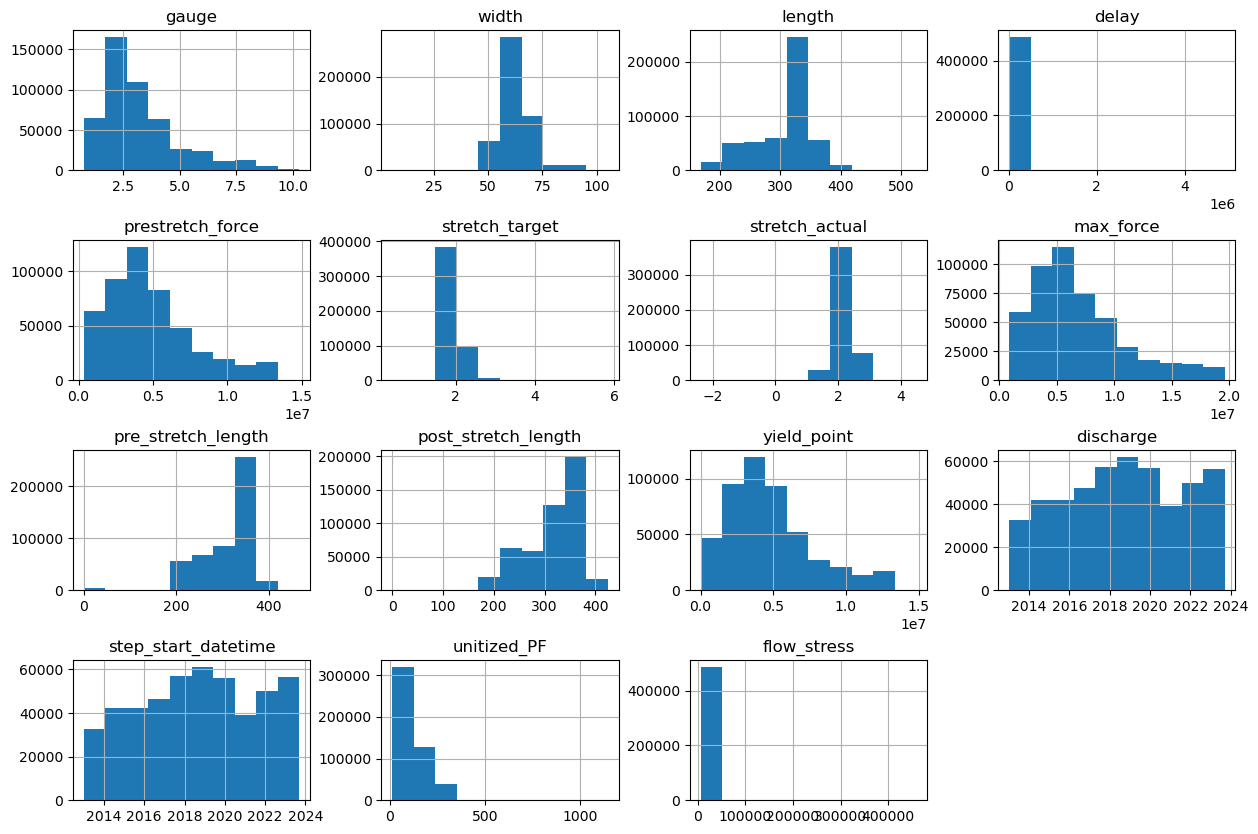

In [41]:
df.hist(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5);

Distributions look good. Data is cleaned and ready for exploration.

In [43]:
df['alloy'].unique()

array(['XR7AT0K50', 'XR6AT0K61', 'XVKKT7H51', 'XVKKT7H55', 'XR7AT0K75',
       'XR2AT0K24', 'XR7AT1K75', 'XR7AT4K75', 'XVKKT2H12', 'XR2AT1K24',
       'XVKKT7H77', 'XVKKT2H14', 'XVKKT6H69', 'XR2AT2K19', 'XVKKT7H52',
       'XVKKT7H90', '#CALC!', 'XVKKT6H61', 'XR2AT0K14', 'XVKKT2H71',
       'XVKKT7H80', 'XR2AT0K50', 'XVKKT2H81', 'XVKKT7H71', 'XVKKT7H91',
       'XR7AT0K17', 'XR6AT1K01'], dtype=object)

In [44]:
df.drop(df[df['alloy'] == '#CALC!'].index, inplace=True)

In [45]:
df['alloy'].unique()

array(['XR7AT0K50', 'XR6AT0K61', 'XVKKT7H51', 'XVKKT7H55', 'XR7AT0K75',
       'XR2AT0K24', 'XR7AT1K75', 'XR7AT4K75', 'XVKKT2H12', 'XR2AT1K24',
       'XVKKT7H77', 'XVKKT2H14', 'XVKKT6H69', 'XR2AT2K19', 'XVKKT7H52',
       'XVKKT7H90', 'XVKKT6H61', 'XR2AT0K14', 'XVKKT2H71', 'XVKKT7H80',
       'XR2AT0K50', 'XVKKT2H81', 'XVKKT7H71', 'XVKKT7H91', 'XR7AT0K17',
       'XR6AT1K01'], dtype=object)

In [46]:
df.dtypes

alloy                           object
job                             object
lot                             object
piece                           object
gauge                          float64
width                          float64
length                         float64
delay                          float64
prestretch_force                 int64
stretch_target                 float64
stretch_actual                 float64
max_force                        int64
step_duration          timedelta64[ns]
pre_stretch_length             float64
post_stretch_length            float64
yield_point                      int64
discharge               datetime64[ns]
step_start_datetime     datetime64[ns]
key                             object
unitized_PF                    float64
flow_stress                      int64
dtype: object

In [47]:
df.to_parquet('../data/cleaned_data.parquet')